<a href="https://colab.research.google.com/github/La-Talia/Pytorch-practice/blob/main/NEural_NEtwork_in_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

In [6]:
#Create a model class that inherits nn.Module
class Model(nn.Module):
  # Input layer = (4 feature of flower)
  # Hidden Layer1 (some number of neurons)
  # Hidden Layer2 (n)
  # Output (3 classes of Iris flower)
  def __init__(self, in_features = 4, h1 = 8, h2 = 9, out_features = 3):
    super().__init__()
    self.fc1  = nn.Linear(in_features ,h1)
    self.fc2  = nn.Linear(h1, h2)
    self.out  = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x

In [7]:
torch.manual_seed(41)
model = Model()


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

In [12]:
my_df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [41]:
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)

In [42]:
X = my_df.drop('variety', axis =1)
y = my_df['variety']

In [43]:
X = X.values
y = y.values

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [46]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.tensor(y_train.astype(float))
y_test = torch.tensor(y_test.astype(float))

In [48]:
criteria = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [51]:
epochs = 100
losses = []
for i in range(epochs):
  y_pred = model.forward(X_train)
  loss = criteria(y_pred, y_train.long())
  losses.append(loss.detach().numpy())
  if i%10==0:
    print('Epoch:', i, " and loss:", loss)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0  and loss: tensor(1.1252, grad_fn=<NllLossBackward0>)
Epoch: 10  and loss: tensor(1.0097, grad_fn=<NllLossBackward0>)
Epoch: 20  and loss: tensor(0.8162, grad_fn=<NllLossBackward0>)
Epoch: 30  and loss: tensor(0.5860, grad_fn=<NllLossBackward0>)
Epoch: 40  and loss: tensor(0.4003, grad_fn=<NllLossBackward0>)
Epoch: 50  and loss: tensor(0.2679, grad_fn=<NllLossBackward0>)
Epoch: 60  and loss: tensor(0.1796, grad_fn=<NllLossBackward0>)
Epoch: 70  and loss: tensor(0.1217, grad_fn=<NllLossBackward0>)
Epoch: 80  and loss: tensor(0.0861, grad_fn=<NllLossBackward0>)
Epoch: 90  and loss: tensor(0.0652, grad_fn=<NllLossBackward0>)


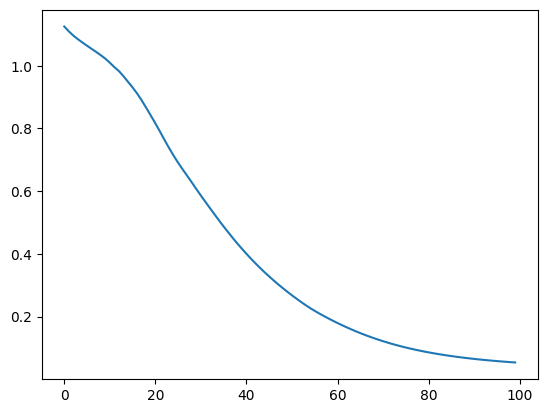

In [52]:
plt.plot(range(epochs), losses)


In [53]:
with torch.no_grad():
  y_eval = model.forward(X_train)
  loss = criteria(y_eval, y_train.long())
print(loss)

tensor(0.0529)


In [61]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)
    print(i+1, '.)', y_val, '\t', int(y_test[i]), '\t', y_val.argmax().item())
    if y_val.argmax().item() == int(y_test[i]):
      correct +=1
print("WE got this correct:",correct)

1 .) tensor([-5.8771,  4.4629,  6.5155]) 	 2 	 2
2 .) tensor([-7.5451,  4.1668,  9.7293]) 	 2 	 2
3 .) tensor([-8.4517,  5.1275, 10.2015]) 	 2 	 2
4 .) tensor([-4.3411,  5.6280,  2.5636]) 	 1 	 1
5 .) tensor([-7.1838,  4.8757,  8.3023]) 	 2 	 2
6 .) tensor([-3.3940,  5.3421,  1.2802]) 	 1 	 1
7 .) tensor([-5.9240,  4.9826,  6.0025]) 	 2 	 2
8 .) tensor([-4.2895,  5.7016,  2.3920]) 	 1 	 1
9 .) tensor([-6.5369,  4.9261,  7.1291]) 	 2 	 2
10 .) tensor([-8.0526,  4.4129, 10.3325]) 	 2 	 2
11 .) tensor([-5.6775,  4.9505,  5.6248]) 	 2 	 2
12 .) tensor([ 4.5748, -2.2579, -2.8925]) 	 0 	 0
13 .) tensor([ 4.2646, -2.0055, -2.7342]) 	 0 	 0
14 .) tensor([-2.1081,  4.0482,  0.5803]) 	 1 	 1
15 .) tensor([ 3.4608, -1.2147, -2.3488]) 	 0 	 0
16 .) tensor([-5.4739,  5.1174,  5.0966]) 	 2 	 1
17 .) tensor([ 4.0637, -1.8045, -2.6504]) 	 0 	 0
18 .) tensor([-5.8090,  4.6057,  6.2494]) 	 1 	 2
19 .) tensor([ 4.9250, -2.5763, -3.0545]) 	 0 	 0
20 .) tensor([ 3.4559, -1.2559, -2.3637]) 	 0 	 0
21 .) ten